# Notebook 1 — Clustering de países por perfil de riesgo de sarampión

## Contexto

El **FIFA World Cup 2026** se celebrará en México, Estados Unidos y Canadá.  
Las ciudades sede mexicanas son **CDMX** (Estadio Azteca), **Guadalajara** (Estadio Akron) y **Monterrey** (Estadio BBVA).

Este notebook construye un perfil de riesgo epidemiológico de sarampión para los países que juegan **partidos en México**, usando:
- Casos confirmados de sarampión 2018–2026 (OMS)
- Cobertura de vacunación MCV1 2018–2023 (OMS)
- Historial de asistencia Qatar 2022 y partidos mundialistas (Kaggle)
- Flujo de pasajeros internacionales a las sedes mexicanas (AICM, MTY, CDMX)
- Historial de brotes locales en las ciudades sede (Boletín Epidemiológico DGE 2016–2026)

El análisis emplea **K-Means** y **Clustering Jerárquico** para agrupar a los países visitantes según su riesgo de importación de sarampión.


---
## 0. Imports y configuración

In [ ]:
import os
import shutil

import pandas                                     as pd
import numpy                                      as np
import matplotlib.pyplot                  as plt
import matplotlib.ticker                    as mticker
import seaborn                                    as sns

from sklearn.preprocessing                                                                                  import StandardScaler
from sklearn.impute                                                                                                import SimpleImputer
from sklearn.cluster                                                                                                import KMeans
from sklearn.metrics                                                                                               import silhouette_score, adjusted_rand_score
from sklearn.decomposition                                                                                 import PCA
from scipy.cluster.hierarchy                                                                                  import linkage, dendrogram, fcluster
from scipy                                                                                                                  import stats

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas ─────────────────────────────────────────────────────────────────
DATA_RAW       = 'content/data/raw/'
DATA_PROCESSED = 'content/data/processed/'
OUTPUT_FIGURES = 'content/reports/figures/'

for path in [DATA_RAW, DATA_PROCESSED, OUTPUT_FIGURES]:
    os.makedirs(path, exist_ok=True)

print("✅ Imports y rutas OK")


✅ Imports y rutas OK


In [ ]:
# ── Mover archivos de /content/ a DATA_RAW ───────────────────────────────
# El nombre en Colab puede tener paréntesis o guiones bajos
ARCHIVOS = [
    # (nombre en /content/,                                nombre destino en DATA_RAW)
    ('WHO_Provisional_measles_and_rubella_data.csv',       'WHO_Provisional_measles_and_rubella_data.csv'),
    ('WHO_vaccination-coverage.csv',                       'WHO_vaccination-coverage.csv'),
    ('Movimiento_operacional_de_pasajeros_de_AICM.csv',    'Movimiento_operacional_de_pasajeros_de_AICM.csv'),
    ('Movimiento_operacional_de_pasajeros_por_terminal.csv','Movimiento_operacional_de_pasajeros_por_terminal.csv'),
    ('Movimiento_operacional_de_vuelos.csv',               'Movimiento_operacional_de_vuelos.csv'),
    ('Llegadas_internacionales_cdmx_mensual.csv',          'Llegadas_internacionales_cdmx_mensual.csv'),
    ('Llegadas_aeropuerto_Extranjeros(Hoja3).csv',         'Llegadas_aeropuerto_Extranjeros_Hoja3_.csv'),
    ('boletin_epidemiologico_2016_2026.csv',               'boletin_epidemiologico_2016_2026.csv'),
    ('boletin_epidemiologico_2016_2026.parquet',           'boletin_epidemiologico_2016_2026.parquet'),
]

print("Copiando archivos a DATA_RAW...")
for src_name, dst_name in ARCHIVOS:
    src = f'/content/{src_name}'
    dst = f'{DATA_RAW}{dst_name}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"  ✅ {src_name}")
    else:
        print(f"  ⚠️  No encontrado: {src_name}")

print(f"\nArchivos en {DATA_RAW}:")
for f in sorted(os.listdir(DATA_RAW)):
    size_kb = os.path.getsize(f'{DATA_RAW}{f}') / 1024
    print(f"  {f:55s} {size_kb:7.1f} KB")

Copiando archivos a DATA_RAW...
  ✅ WHO_Provisional_measles_and_rubella_data.csv
  ✅ WHO_vaccination-coverage.csv
  ✅ Movimiento_operacional_de_pasajeros_de_AICM.csv
  ✅ Movimiento_operacional_de_pasajeros_por_terminal.csv
  ✅ Movimiento_operacional_de_vuelos.csv
  ✅ Llegadas_internacionales_cdmx_mensual.csv
  ✅ Llegadas_aeropuerto_Extranjeros(Hoja3).csv
  ✅ boletin_epidemiologico_2016_2026.csv
  ✅ boletin_epidemiologico_2016_2026.parquet

Archivos en content/data/raw/:
  Llegadas_aeropuerto_Extranjeros_Hoja3_.csv                  0.6 KB
  Llegadas_internacionales_cdmx_mensual.csv                   2.2 KB
  Movimiento_operacional_de_pasajeros_de_AICM.csv             3.7 KB
  Movimiento_operacional_de_pasajeros_por_terminal.csv        8.3 KB
  Movimiento_operacional_de_vuelos.csv                        3.2 KB
  WHO_Provisional_measles_and_rubella_data.csv             1187.0 KB
  WHO_vaccination-coverage.csv                              346.7 KB
  boletin_epidemiologico_2016_2026.csv    

---
## 1. Carga y limpieza de datos

### 1.1 Casos de sarampión — OMS

In [ ]:
measles_raw = pd.read_csv(
    DATA_RAW + 'WHO_Provisional_measles_and_rubella_data.csv',
    sep=';',
    encoding='utf-8-sig',
)

# Limpiar nombres de columnas
measles_raw.columns = [c.replace('\n', ' ').strip() for c in measles_raw.columns]

measles = measles_raw.rename(columns={
    'Measles  total'        : 'measles_total',
    'Measles  lab-confirmed': 'measles_lab',
    'Measles  epi-linked'   : 'measles_epi',
    'Measles  clinical'     : 'measles_clinical',
    'Measles  suspect'      : 'measles_suspect',
}).copy()

for col in ['measles_total','measles_lab','measles_epi','measles_clinical']:
    measles[col] = pd.to_numeric(measles[col], errors='coerce').fillna(0)

print(f"WHO measles: {measles.shape}  | años {measles['Year'].min()}–{measles['Year'].max()}")
print(f"Países: {measles['Country'].nunique()}")
measles.head(3)


WHO measles: (24088, 17)  | años 2012–2026
Países: 193


,Region,Country,ISO3,Year,Month,measles_suspect,measles_clinical,measles_epi,measles_lab,measles_total,Rubella clinical,Rubella epi-linked,Rubella lab-confirmed,Rubella Total,Discarded,Unnamed: 15,Unnamed: 16
0,AFR,Algeria,DZA,2012,1,8.00,6.00,0.00,2.00,8.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN
1,AFR,Algeria,DZA,2012,2,10.00,10.00,0.00,0.00,10.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN
2,AFR,Algeria,DZA,2012,3,17.00,17.00,0.00,0.00,17.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN


### 1.2 Cobertura de vacunación — OMS

In [ ]:
vax_raw = pd.read_csv(DATA_RAW + 'WHO_vaccination-coverage.csv')

vax = vax_raw.rename(columns={
    'Entity'                     : 'Country',
    'Code'                       : 'ISO3',
    'Measles, first dose (MCV1)' : 'mcv1',
}).copy()

vax['mcv1'] = pd.to_numeric(vax['mcv1'], errors='coerce')

print(f"WHO vax: {vax.shape}  | años {vax['Year'].min()}–{vax['Year'].max()}")
vax.head(3)


WHO vax: (8825, 13)  | años 1980–2023


,Country,ISO3,Year,mcv1,Hepatitis B (HepB3),H. influenza type b (Hib3),Inactivated polio vaccine (IPV),Pneumococcal vaccine (PCV3),Polio (Pol3),Rubella (RCV1),Rotavirus (RotaC),Yellow fever (YFV),Diptheria/tetanus/pertussis (DTP3)
0,Afghanistan,AFG,1980,11.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00
1,Afghanistan,AFG,1981,NaN,NaN,NaN,NaN,NaN,3.00,NaN,NaN,NaN,3.00
2,Afghanistan,AFG,1982,8.00,NaN,NaN,NaN,NaN,5.00,NaN,NaN,NaN,5.00


### 1.3 Partidos confirmados y datos Kaggle — Mundial 2026

In [ ]:
# ── Partidos confirmados en sedes mexicanas ────────────────────────────────
partidos_data = [
    {'fecha': '2026-06-11', 'ciudad': 'CDMX',        'partido': 'MEX vs RSA'},
    {'fecha': '2026-06-11', 'ciudad': 'Guadalajara',  'partido': 'KOR vs EUR'},
    {'fecha': '2026-06-14', 'ciudad': 'Monterrey',    'partido': 'UKR vs TUN'},
    {'fecha': '2026-06-17', 'ciudad': 'CDMX',        'partido': 'UZB vs COL'},
    {'fecha': '2026-06-18', 'ciudad': 'Guadalajara',  'partido': 'MEX vs KOR'},
    {'fecha': '2026-06-20', 'ciudad': 'Monterrey',    'partido': 'TUN vs JPN'},
    {'fecha': '2026-06-24', 'ciudad': 'CDMX',        'partido': 'EUR vs MEX'},
    {'fecha': '2026-06-24', 'ciudad': 'Monterrey',    'partido': 'RSA vs KOR'},
    {'fecha': '2026-06-30', 'ciudad': 'CDMX',        'partido': '16vos Final'},
    {'fecha': '2026-07-05', 'ciudad': 'CDMX',        'partido': '8vos Final'},
]

# Expandir a home/away con nombres completos FIFA
partidos_mexico = [
    {'fecha': '2026-06-11', 'ciudad': 'CDMX',        'home': 'Mexico',         'away': 'South Africa'},
    {'fecha': '2026-06-11', 'ciudad': 'Guadalajara',  'home': 'South Korea',    'away': None},
    {'fecha': '2026-06-14', 'ciudad': 'Monterrey',    'home': 'Ukraine',        'away': 'Tunisia'},
    {'fecha': '2026-06-17', 'ciudad': 'CDMX',        'home': 'Uzbekistan',     'away': 'Colombia'},
    {'fecha': '2026-06-18', 'ciudad': 'Guadalajara',  'home': 'Mexico',         'away': 'South Korea'},
    {'fecha': '2026-06-20', 'ciudad': 'Monterrey',    'home': 'Japan',          'away': 'Tunisia'},
    {'fecha': '2026-06-24', 'ciudad': 'CDMX',        'home': None,             'away': 'Mexico'},
    {'fecha': '2026-06-24', 'ciudad': 'Monterrey',    'home': 'South Africa',   'away': 'South Korea'},
]

df_partidos_mexico = pd.DataFrame(partidos_mexico)
df_partidos_mexico['fecha'] = pd.to_datetime(df_partidos_mexico['fecha'])

equipos_confirmados = [
    'Mexico', 'South Africa', 'South Korea', 'Ukraine',
    'Tunisia', 'Uzbekistan', 'Colombia', 'Japan',
]

# Ciudad sede principal (donde juega más partidos)
equipos_por_ciudad = (
    pd.concat([
        df_partidos_mexico[['ciudad','home']].rename(columns={'home':'Country'}),
        df_partidos_mexico[['ciudad','away']].rename(columns={'away':'Country'})
    ])
    .dropna(subset=['Country'])
    .query("Country in @equipos_confirmados")
    .groupby(['Country','ciudad'])
    .size()
    .reset_index(name='partidos_en_mexico')
)

ciudad_principal = (
    equipos_por_ciudad
    .sort_values('partidos_en_mexico', ascending=False)
    .groupby('Country').first()
    .reset_index()[['Country','ciudad']]
    .rename(columns={'ciudad':'ciudad_sede'})
)

print("Partidos por equipo y ciudad sede:")
print(equipos_por_ciudad.sort_values(['Country','ciudad']).to_string(index=False))


Partidos por equipo y ciudad sede:
     Country      ciudad  partidos_en_mexico
    Colombia        CDMX                   1
       Japan   Monterrey                   1
      Mexico        CDMX                   2
      Mexico Guadalajara                   1
South Africa        CDMX                   1
South Africa   Monterrey                   1
 South Korea Guadalajara                   2
 South Korea   Monterrey                   1
     Tunisia   Monterrey                   2
     Ukraine   Monterrey                   1
  Uzbekistan        CDMX                   1


In [ ]:
# ── Kaggle: Asistencia promedio Qatar 2022 ────────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter

df_qatar = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "parasharmanas/qatar-2022-fifa-world-cup-attendance",
    "Attendance Sheet.csv"
)

home_teams = df_qatar[['Home', 'Attendance']].rename(columns={'Home': 'Country'})
away_teams = df_qatar[['Away', 'Attendance']].rename(columns={'Away': 'Country'})

asistencia_qatar = (
    pd.concat([home_teams, away_teams])
    .assign(Attendance=lambda x: pd.to_numeric(
        x['Attendance'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    ))
    .groupby('Country')
    .agg(asistencia_promedio=('Attendance', 'mean'))
    .reset_index()
    .query("Country in @equipos_confirmados")
)

print("Asistencia promedio Qatar 2022 — equipos en México:")
print(asistencia_qatar.sort_values('asistencia_promedio', ascending=False).to_string(index=False))


/tmp/ipykernel_1713/3301695543.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_qatar = kagglehub.load_dataset(


100%|██████████| 4.93k/4.93k [00:00<00:00, 10.9MB/s]

Asistencia promedio Qatar 2022 — equipos en México:
Country  asistencia_promedio
 Mexico             71106.67
  Japan             42865.25
Tunisia             42791.67


In [ ]:
# ── Kaggle: Historial mundialista 1930–2018 ───────────────────────────────
path = kagglehub.dataset_download("evangower/fifa-world-cup")
wc_matches = pd.read_csv(path + "/wcmatches.csv")

all_hist_teams = (
    pd.concat([
        wc_matches[['home_team']].rename(columns={'home_team': 'Country'}),
        wc_matches[['away_team']].rename(columns={'away_team': 'Country'})
    ])
    .value_counts()
    .reset_index()
)
all_hist_teams.columns = ['Country', 'partidos_historicos']

hist_wc_mexico = all_hist_teams.query("Country in @equipos_confirmados")

print("Historial mundialista — equipos en México:")
print(hist_wc_mexico.sort_values('partidos_historicos', ascending=False).to_string(index=False))


100%|██████████| 15.4k/15.4k [00:00<00:00, 30.7MB/s]

Extracting files...
Historial mundialista — equipos en México:
     Country  partidos_historicos
      Mexico                   57
 South Korea                   34
    Colombia                   22
       Japan                   21
     Tunisia                   15
South Africa                    9
     Ukraine                    5


In [ ]:
# ── wc_participation: une las tres fuentes ────────────────────────────────
wc_participation = (
    pd.DataFrame({'Country': equipos_confirmados})
    .merge(ciudad_principal, on='Country', how='left')
    .merge(
        equipos_por_ciudad.groupby('Country')['partidos_en_mexico'].sum().reset_index(),
        on='Country', how='left'
    )
    .merge(asistencia_qatar,                               on='Country', how='left')
    .merge(all_hist_teams[['Country','partidos_historicos']], on='Country', how='left')
    .fillna({'asistencia_promedio': 0, 'partidos_historicos': 0})
    .assign(clasificado_2026=1)
)

wc_participation['partidos_historicos'] = wc_participation['partidos_historicos'].astype(int)
wc_participation['partidos_en_mexico']  = wc_participation['partidos_en_mexico'].astype(int)

print(f"Equipos en wc_participation: {len(wc_participation)}")
print(wc_participation.sort_values('partidos_historicos', ascending=False).to_string(index=False))


Equipos en wc_participation: 8
     Country ciudad_sede  partidos_en_mexico  asistencia_promedio  partidos_historicos  clasificado_2026
      Mexico        CDMX                   3             71106.67                   57                 1
 South Korea Guadalajara                   3                 0.00                   34                 1
    Colombia        CDMX                   1                 0.00                   22                 1
       Japan   Monterrey                   1             42865.25                   21                 1
     Tunisia   Monterrey                   2             42791.67                   15                 1
South Africa        CDMX                   2                 0.00                    9                 1
     Ukraine   Monterrey                   1                 0.00                    5                 1
  Uzbekistan        CDMX                   1                 0.00                    0                 1


### 1.4 Flujo de pasajeros internacionales a las sedes

In [ ]:
MES_MAP = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

# 1) AICM mensual (2015–2026)
aicm = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_de_AICM.csv')
aicm['mes_num'] = aicm['mes'].str.lower().map(MES_MAP)
aicm['fecha']   = pd.to_datetime(
    aicm[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1)
)
aicm = aicm[['fecha','pasajeros_nacionales','pasajeros_internacionales']].sort_values('fecha').reset_index(drop=True)
print(f"AICM mensual:  {aicm['fecha'].min().date()} → {aicm['fecha'].max().date()}  ({len(aicm)} filas)")

# 2) Por terminal T1/T2 (2016–2026)
terminal = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_por_terminal.csv')
terminal['mes_num'] = terminal['mes'].str.lower().map(MES_MAP)
terminal['fecha']   = pd.to_datetime(
    terminal[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1)
)
terminal['intl_total_terminal'] = (
    terminal['pasajeros_llegadas_internacionales_t1'] +
    terminal['pasajeros_llegadas_internacionales_t2']
)
terminal = terminal[['fecha','intl_total_terminal']].sort_values('fecha').reset_index(drop=True)
print(f"Terminal:      {terminal['fecha'].min().date()} → {terminal['fecha'].max().date()}  ({len(terminal)} filas)")

# 3) Vuelos internacionales (2015–2026)
vuelos = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_vuelos.csv')
vuelos['mes_num'] = vuelos['mes'].str.lower().map(MES_MAP)
vuelos['fecha']   = pd.to_datetime(
    vuelos[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1)
)
vuelos = vuelos[['fecha','operaciones_vuelos_internacionales']].sort_values('fecha').reset_index(drop=True)
print(f"Vuelos:        {vuelos['fecha'].min().date()} → {vuelos['fecha'].max().date()}  ({len(vuelos)} filas)")

# 4) Llegadas internacionales CDMX mensual (2018–2024)
cdmx = pd.read_csv(DATA_RAW + 'Llegadas_internacionales_cdmx_mensual.csv')
cdmx['fecha'] = pd.to_datetime(cdmx['fecha'])
cdmx = cdmx[['fecha','ciudad_de_mexico']].rename(columns={'ciudad_de_mexico':'intl_cdmx'}).sort_values('fecha').reset_index(drop=True)
print(f"CDMX intl:     {cdmx['fecha'].min().date()} → {cdmx['fecha'].max().date()}  ({len(cdmx)} filas)")

# 5) Monterrey — datos anuales (2012–2024)
mty_raw = pd.read_csv(DATA_RAW + 'Llegadas_aeropuerto_Extranjeros_Hoja3_.csv', sep=';', encoding='utf-8-sig')
mty_raw.columns = [c.strip() for c in mty_raw.columns]
mty_raw = mty_raw.rename(columns={
    'Periodo'                              : 'anio',
    'Llegada de Pasajeros Internacionales' : 'pax_internacionales',
})
mty_raw['pax_internacionales'] = (
    mty_raw['pax_internacionales'].astype(str)
    .str.replace('.', '', regex=False).str.strip()
    .astype(int)
)
print(f"MTY anual:     {mty_raw['anio'].min()} → {mty_raw['anio'].max()}  ({len(mty_raw)} filas)")


AICM mensual:  2015-01-01 → 2026-01-01  (133 filas)
Terminal:      2016-01-01 → 2026-01-01  (121 filas)
Vuelos:        2015-01-01 → 2026-01-01  (133 filas)
CDMX intl:     2018-09-30 → 2024-06-30  (70 filas)
MTY anual:     2012 → 2024  (13 filas)


In [ ]:
# Distribuir MTY anual → mensual usando patrón estacional del AICM
aicm['mes_num'] = aicm['fecha'].dt.month
estacional = (
    aicm.groupby('mes_num')['pasajeros_internacionales'].mean()
)
estacional = (estacional / estacional.sum()).rename('peso_mes')

mty_mensual_rows = []
for _, row in mty_raw.iterrows():
    for mes_num, peso in estacional.items():
        mty_mensual_rows.append({
            'fecha'            : pd.Timestamp(year=int(row['anio']), month=int(mes_num), day=1),
            'pax_int_mty'      : round(row['pax_internacionales'] * peso),
        })

mty_mensual = pd.DataFrame(mty_mensual_rows).sort_values('fecha').reset_index(drop=True)
print(f"MTY mensual (estimado): {mty_mensual['fecha'].min().date()} → {mty_mensual['fecha'].max().date()}")

# Consolidar: anual por sede
aicm['anio'] = aicm['fecha'].dt.year
mty_mensual['anio'] = mty_mensual['fecha'].dt.year

aicm_anual = aicm.groupby('anio')['pasajeros_internacionales'].sum().reset_index().rename(
    columns={'pasajeros_internacionales': 'pax_int_cdmx'})
mty_anual  = mty_mensual.groupby('anio')['pax_int_mty'].sum().reset_index()

pasajeros = (
    aicm_anual
    .merge(mty_anual, on='anio', how='outer')
    .sort_values('anio')
)
# GDL estimado como 35% del flujo AICM
pasajeros['pax_int_gdl'] = (pasajeros['pax_int_cdmx'] * 0.35).round(0)

print("\nFlujo anual por sede (2018–2026):")
print(pasajeros[pasajeros['anio'] >= 2018].to_string(index=False))


MTY mensual (estimado): 2012-01-01 → 2024-12-01

Flujo anual por sede (2018–2026):
 anio  pax_int_cdmx  pax_int_mty  pax_int_gdl
 2018   17204824.00   1331794.00   6021688.00
 2019   17647782.00   1419988.00   6176724.00
 2020    5794875.00    505997.00   2028206.00
 2021   10172889.00   1294525.00   3560511.00
 2022   14563933.00   1397955.00   5097377.00
 2023   16332734.00   1849658.00   5716457.00
 2024   17116325.00   2224830.00   5990714.00
 2025   17482146.00          NaN   6118751.00
 2026    1545153.00          NaN    540804.00


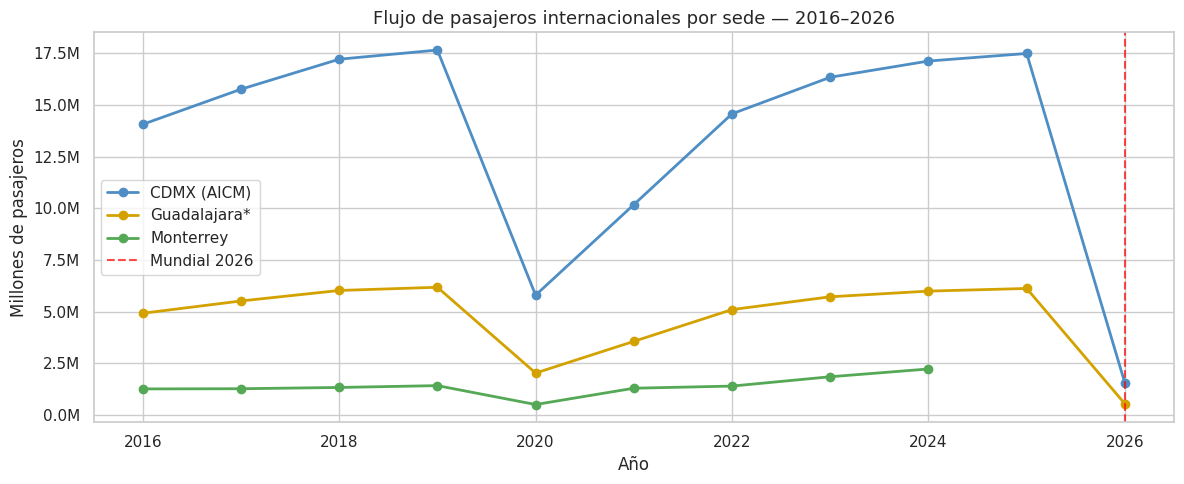

* GDL estimado como 35% del flujo AICM


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}

for col, label, color in [
    ('pax_int_cdmx', 'CDMX (AICM)',   colors['CDMX']),
    ('pax_int_gdl',  'Guadalajara*',  colors['Guadalajara']),
    ('pax_int_mty',  'Monterrey',     colors['Monterrey']),
]:
    sub = pasajeros[pasajeros[col].notna() & (pasajeros['anio'] >= 2016)]
    ax.plot(sub['anio'], sub[col]/1e6, marker='o', label=label, color=color, linewidth=2)

ax.axvline(2026, color='red', linestyle='--', alpha=0.7, label='Mundial 2026')
ax.set_title('Flujo de pasajeros internacionales por sede — 2016–2026', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Millones de pasajeros')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/pasajeros_sedes.png', dpi=150)
plt.show()
print("* GDL estimado como 35% del flujo AICM")


### 1.5 Brotes locales de sarampión en sedes — Boletín DGE 2016–2026

In [ ]:
boletin = pd.read_csv(DATA_RAW + 'boletin_epidemiologico_2016_2026.csv')

SEDES_MAP = {
    'Ciudad de México' : 'CDMX',
    'Jalisco'          : 'Guadalajara',
    'Nuevo León'       : 'Monterrey',
}

sar_local = (
    boletin[
        (boletin['enfermedad'] == 'Sarampion') &
        (boletin['sexo'] == 'H') &
        (boletin['entidad_federativa'].isin(SEDES_MAP.keys()))
    ]
    .copy()
)
sar_local['ciudad_sede'] = sar_local['entidad_federativa'].map(SEDES_MAP)

sar_anual = (
    sar_local
    .groupby(['anio','ciudad_sede'])['casos_semana']
    .sum()
    .reset_index()
    .rename(columns={'casos_semana': 'casos_sar_local'})
)

sar_pivot = (
    sar_anual
    .pivot(index='anio', columns='ciudad_sede', values='casos_sar_local')
    .fillna(0).astype(int)
)

print("Casos de Sarampión confirmados por sede y año (Boletín DGE):")
print(sar_pivot.to_string())


Casos de Sarampión confirmados por sede y año (Boletín DGE):
ciudad_sede  CDMX  Guadalajara  Monterrey
anio                                     
2016            0            0          0
2017            0            0          0
2018            0            0          0
2019            0            0          0
2020           57            0          0
2021            0            0          0
2022            0            0          0
2023            0            0          0
2024            1            0          0
2025            8          205          0
2026           96          934         13


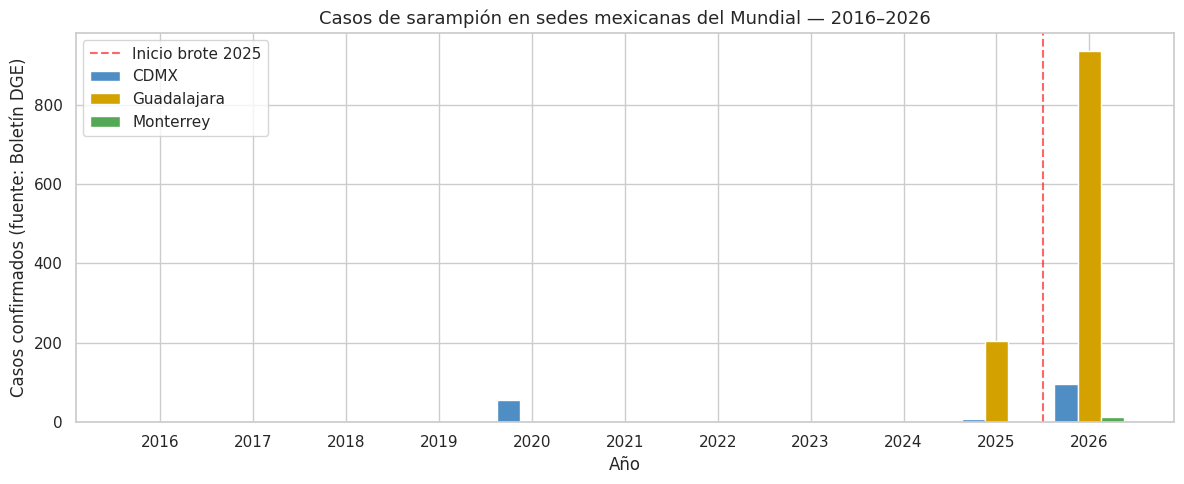

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
colors_sede = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}
sedes_order = ['CDMX', 'Guadalajara', 'Monterrey']
n_sedes = len(sedes_order)
bar_width = 0.25

for i, ciudad in enumerate(sedes_order):
    if ciudad in sar_pivot.columns:
        offset = (i - n_sedes//2) * bar_width
        ax.bar(sar_pivot.index + offset, sar_pivot[ciudad],
               width=bar_width, label=ciudad, color=colors_sede[ciudad])

ax.axvline(2025.5, color='red', linestyle='--', alpha=0.6, label='Inicio brote 2025')
ax.set_title('Casos de sarampión en sedes mexicanas del Mundial — 2016–2026', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Casos confirmados (fuente: Boletín DGE)')
ax.legend()
ax.set_xticks(range(2016, 2027))
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/sarampion_sedes_local.png', dpi=150)
plt.show()


---
## 2. Construcción del dataset para clustering

| Feature | Fuente | Interpretación |
|---|---|---|
| `total_cases` | WHO measles 2018–2024 | Carga total de sarampión |
| `avg_monthly_cases` | WHO measles 2018–2024 | Intensidad mensual promedio |
| `months_with_cases` | WHO measles 2018–2024 | Persistencia del brote |
| `mcv1_mean` | WHO vax 2018–2023 | Cobertura MCV1 promedio |
| `mcv1_min` | WHO vax 2018–2023 | Año más vulnerable |
| `mcv1_tendencia` | WHO vax 2018–2023 | ¿Mejora o empeora? |
| `asistencia_promedio` | Qatar 2022 (Kaggle) | Proxy tamaño de hinchada |
| `partidos_en_mexico` | FIFA 2026 | Partidos que juega en México |
| `partidos_historicos` | FIFA 1930–2018 (Kaggle) | Experiencia mundialista |


In [ ]:
# Incidencia de sarampión 2018-2024
measles_recent = measles[measles['Year'].between(2018, 2024)].copy()

measles_by_country = (
    measles_recent
    .groupby('Country')
    .agg(
        total_cases      = ('measles_total', 'sum'),
        avg_monthly_cases= ('measles_total', 'mean'),
        months_with_cases= ('measles_total', lambda x: (x > 0).sum()),
        peak_month       = ('measles_total', 'max'),
    )
    .reset_index()
)

# Mapeo FIFA → WHO measles (usan "Republic of Korea")
nombre_who_measles = {
    'Mexico'      : 'Mexico',
    'South Africa': 'South Africa',
    'South Korea' : 'Republic of Korea',
    'Ukraine'     : 'Ukraine',
    'Tunisia'     : 'Tunisia',
    'Uzbekistan'  : 'Uzbekistan',
    'Colombia'    : 'Colombia',
    'Japan'       : 'Japan',
}

# Mapeo FIFA → WHO vax (usan "South Korea")
nombre_who_vax = {
    'Mexico'      : 'Mexico',
    'South Africa': 'South Africa',
    'South Korea' : 'South Korea',
    'Ukraine'     : 'Ukraine',
    'Tunisia'     : 'Tunisia',
    'Uzbekistan'  : 'Uzbekistan',
    'Colombia'    : 'Colombia',
    'Japan'       : 'Japan',
}

paises_who_measles = list(nombre_who_measles.values())
print("Casos de sarampión 2018-2024 — equipos en México:")
print(measles_by_country[measles_by_country['Country'].isin(paises_who_measles)]
      .sort_values('total_cases', ascending=False).to_string(index=False))

Casos de sarampión 2018-2024 — equipos en México:
          Country  total_cases  avg_monthly_cases  months_with_cases  peak_month
          Ukraine    111326.00            1325.31                 73    13760.00
       Uzbekistan      8480.00             136.77                 48     1618.00
          Tunisia      4756.00              58.72                 56     1211.00
     South Africa      2475.00              31.73                 75      285.00
            Japan      1143.00              13.61                 54      147.00
         Colombia       447.00               6.21                 23       43.00
Republic of Korea       273.00               3.25                 33       53.00
           Mexico       223.00               3.10                 12      139.00


In [ ]:
# Cobertura MCV1 2018-2023 y tendencia lineal
vax_recent = vax[vax['Year'].between(2018, 2023)].copy()

def calc_slope(group):
    g = group.dropna(subset=['mcv1'])
    if len(g) < 3:
        return np.nan
    slope, *_ = stats.linregress(g['Year'], g['mcv1'])
    return slope

vax_slope = (
    vax_recent
    .groupby('Country')
    .apply(calc_slope)
    .reset_index()
    .rename(columns={0: 'mcv1_tendencia'})
)

vax_by_country = (
    vax_recent
    .groupby('Country')
    .agg(
        mcv1_mean = ('mcv1', 'mean'),
        mcv1_min  = ('mcv1', 'min'),
        mcv1_std  = ('mcv1', 'std'),
    )
    .reset_index()
    .merge(vax_slope, on='Country', how='left')
)

print("Cobertura MCV1 2018-2023 — equipos en México:")
print(vax_by_country[vax_by_country['Country'].isin(paises_who)]
      .sort_values('mcv1_mean').to_string(index=False))


Cobertura MCV1 2018-2023 — equipos en México:
     Country  mcv1_mean  mcv1_min  mcv1_std  mcv1_tendencia
South Africa      83.50     80.00      2.74            0.20
      Mexico      87.17     73.00     10.83           -1.69
     Ukraine      87.17     74.00      7.08           -1.40
    Colombia      91.17     86.00      3.76           -1.00
       Japan      96.33     94.00      1.63           -0.34
     Tunisia      96.33     95.00      1.37           -0.34
  Uzbekistan      98.33     96.00      1.21            0.51


/tmp/ipykernel_1713/301178704.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_slope)


In [ ]:
# Join completo: equipos × WHO measles × WHO vax × Kaggle × aeropuertos × boletín
base = pd.DataFrame({
    'Country'     : list(nombre_who_measles.keys()),
    'who_measles' : list(nombre_who_measles.values()),
    'who_vax'     : list(nombre_who_vax.values()),
})

# Brote local acumulado 2025-2026 por sede
sar_reciente = (
    sar_anual[sar_anual['anio'] >= 2025]
    .groupby('ciudad_sede')['casos_sar_local']
    .sum()
    .reset_index()
    .rename(columns={'casos_sar_local': 'brote_local_2025_26'})
)

# Flujo de pasajeros 2023 por sede
pax_2023 = pasajeros[pasajeros['anio'] == 2023].iloc[0]
pax_sede_dict = {
    'CDMX'       : pax_2023['pax_int_cdmx'],
    'Guadalajara': pax_2023['pax_int_gdl'],
    'Monterrey'  : pax_2023['pax_int_mty'],
}

cluster_df = (
    base
    .merge(wc_participation[['Country','ciudad_sede','partidos_en_mexico']], on='Country', how='left')
    .merge(asistencia_qatar,  on='Country', how='left')
    .merge(all_hist_teams[['Country','partidos_historicos']], on='Country', how='left')
    .merge(measles_by_country.rename(columns={'Country': 'who_measles'}), on='who_measles', how='left')
    .merge(vax_by_country.rename(columns={'Country': 'who_vax'}),         on='who_vax',     how='left')
    .merge(sar_reciente, on='ciudad_sede', how='left')
    .assign(
        pax_int_sede_2023   = lambda x: x['ciudad_sede'].map(pax_sede_dict),
        brote_local_2025_26 = lambda x: x['brote_local_2025_26'].fillna(0).astype(int),
        clasificado_2026    = 1,
    )
    .set_index('Country')
)

print("Dataset de clustering:")
cols_preview = ['ciudad_sede','total_cases','mcv1_mean','asistencia_promedio',
                'partidos_historicos','brote_local_2025_26']
print(cluster_df[cols_preview].to_string())

Dataset de clustering:
              ciudad_sede  total_cases  mcv1_mean  asistencia_promedio  partidos_historicos  brote_local_2025_26
Country                                                                                                         
Mexico               CDMX       223.00      87.17             71106.67                57.00                  104
South Africa         CDMX      2475.00      83.50                  NaN                 9.00                  104
South Korea   Guadalajara       273.00      97.67                  NaN                34.00                 1139
Ukraine         Monterrey    111326.00      87.17                  NaN                 5.00                   13
Tunisia         Monterrey      4756.00      96.33             42791.67                15.00                   13
Uzbekistan           CDMX      8480.00      98.33                  NaN                  NaN                  104
Colombia             CDMX       447.00      91.17                  NaN   

---
## 3. Análisis exploratorio de las features de clustering

Antes de aplicar K-Means exploramos visualmente las features para entender:
- **Distribución**: ¿sesgada? ¿outliers?
- **Relación vacunación–incidencia**: los dos ejes más importantes del riesgo
- **Correlación**: variables redundantes

Con solo 8 equipos usamos barras comparativas en lugar de histogramas.


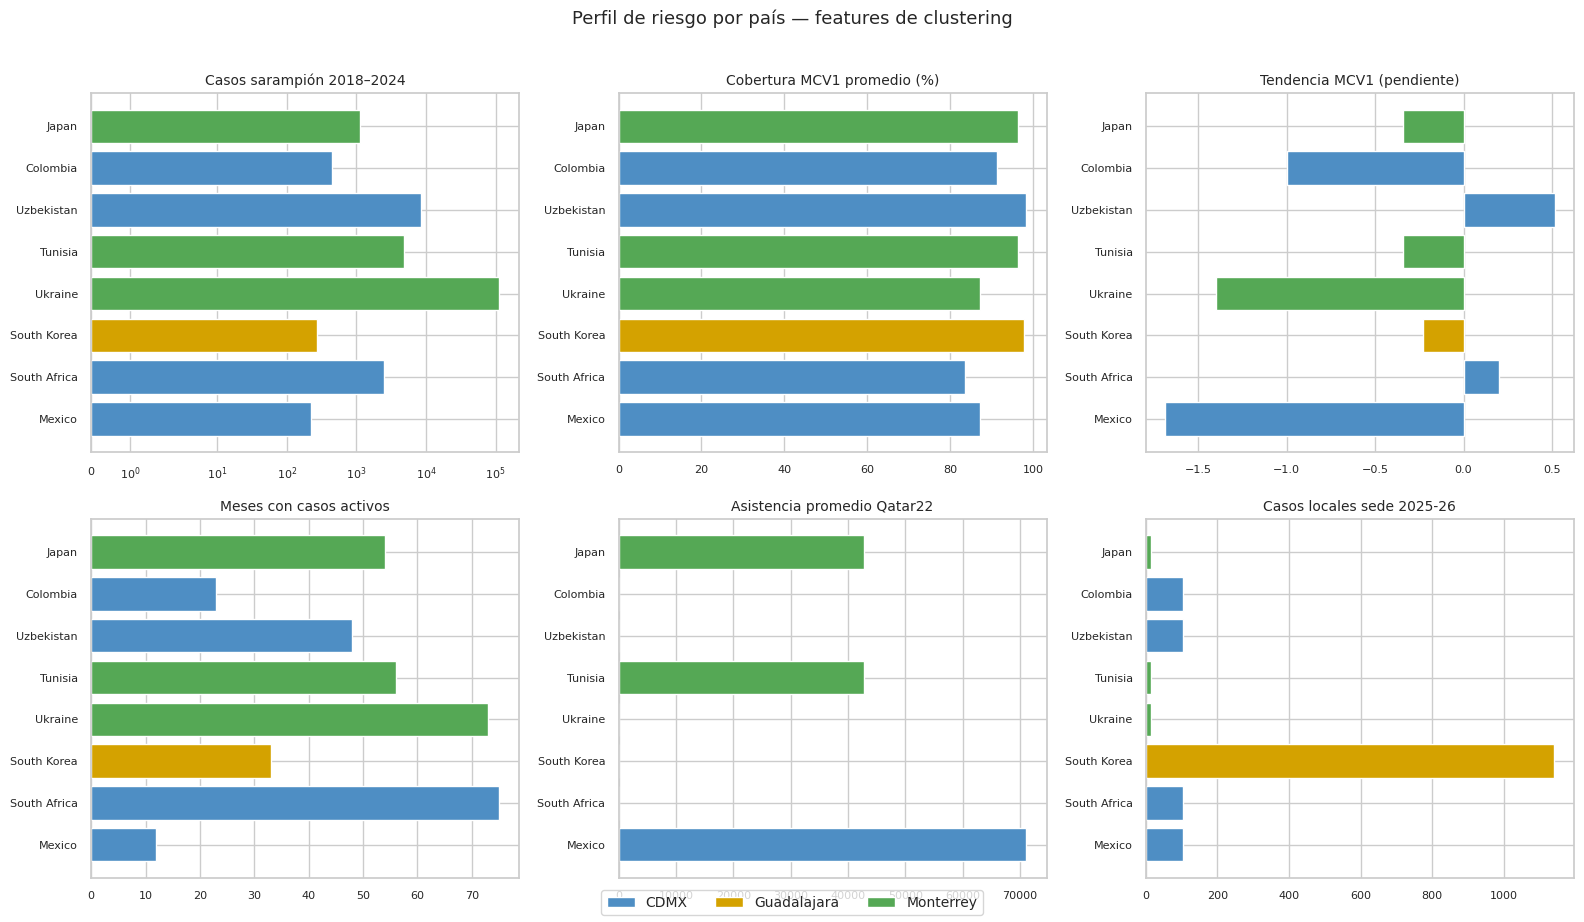

In [ ]:
ciudad_colors = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}

feature_cols = [
    ('total_cases',          'Casos sarampión 2018–2024',   'log'),
    ('mcv1_mean',            'Cobertura MCV1 promedio (%)', 'linear'),
    ('mcv1_tendencia',       'Tendencia MCV1 (pendiente)',  'linear'),
    ('months_with_cases',    'Meses con casos activos',     'linear'),
    ('asistencia_promedio',  'Asistencia promedio Qatar22', 'linear'),
    ('brote_local_2025_26',  'Casos locales sede 2025-26',  'linear'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (col, label, scale) in zip(axes.flat, feature_cols):
    vals = cluster_df[col].fillna(0)
    colors_bar = [ciudad_colors.get(cluster_df.loc[c, 'ciudad_sede'], '#aaa') for c in vals.index]
    ax.barh(vals.index, vals, color=colors_bar)
    ax.set_title(label, fontsize=10)
    if scale == 'log':
        ax.set_xscale('symlog')
    ax.tick_params(labelsize=8)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in ciudad_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10)
fig.suptitle('Perfil de riesgo por país — features de clustering', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/features_comparativas.png', dpi=150, bbox_inches='tight')
plt.show()


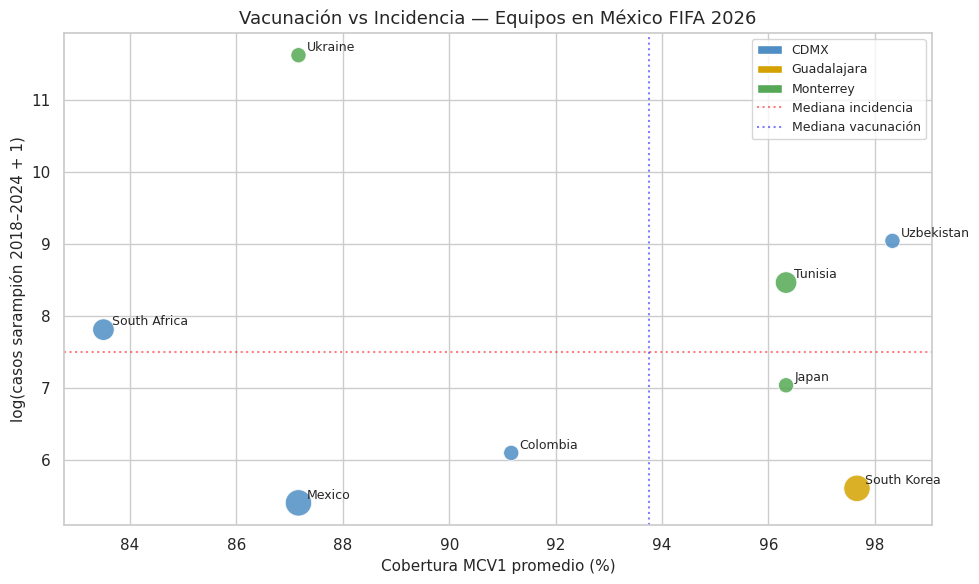

In [ ]:
# Scatter: vacunación vs incidencia
fig, ax = plt.subplots(figsize=(10, 6))

point_colors = [ciudad_colors.get(c, '#aaa') for c in cluster_df['ciudad_sede']]
sizes = np.clip(cluster_df['partidos_en_mexico'].fillna(1) * 120, 100, 500)

ax.scatter(
    cluster_df['mcv1_mean'],
    np.log1p(cluster_df['total_cases']),
    c=point_colors, s=sizes, alpha=0.85,
    edgecolors='white', linewidths=0.6, zorder=3
)

for country, row in cluster_df.iterrows():
    ax.annotate(
        country,
        (row['mcv1_mean'], np.log1p(row['total_cases'])),
        xytext=(6, 3), textcoords='offset points', fontsize=9
    )

ax.axhline(np.log1p(cluster_df['total_cases'].median()), color='red',
           linestyle=':', alpha=0.5, label='Mediana incidencia')
ax.axvline(cluster_df['mcv1_mean'].median(), color='blue',
           linestyle=':', alpha=0.5, label='Mediana vacunación')

ax.set_xlabel('Cobertura MCV1 promedio (%)', fontsize=11)
ax.set_ylabel('log(casos sarampión 2018–2024 + 1)', fontsize=11)
ax.set_title('Vacunación vs Incidencia — Equipos en México FIFA 2026', fontsize=13)

from matplotlib.patches import Patch
legend_colors = [Patch(facecolor=v, label=k) for k, v in ciudad_colors.items()]
ax.legend(handles=legend_colors + ax.get_lines(), fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/scatter_vax_incidencia.png', dpi=150)
plt.show()


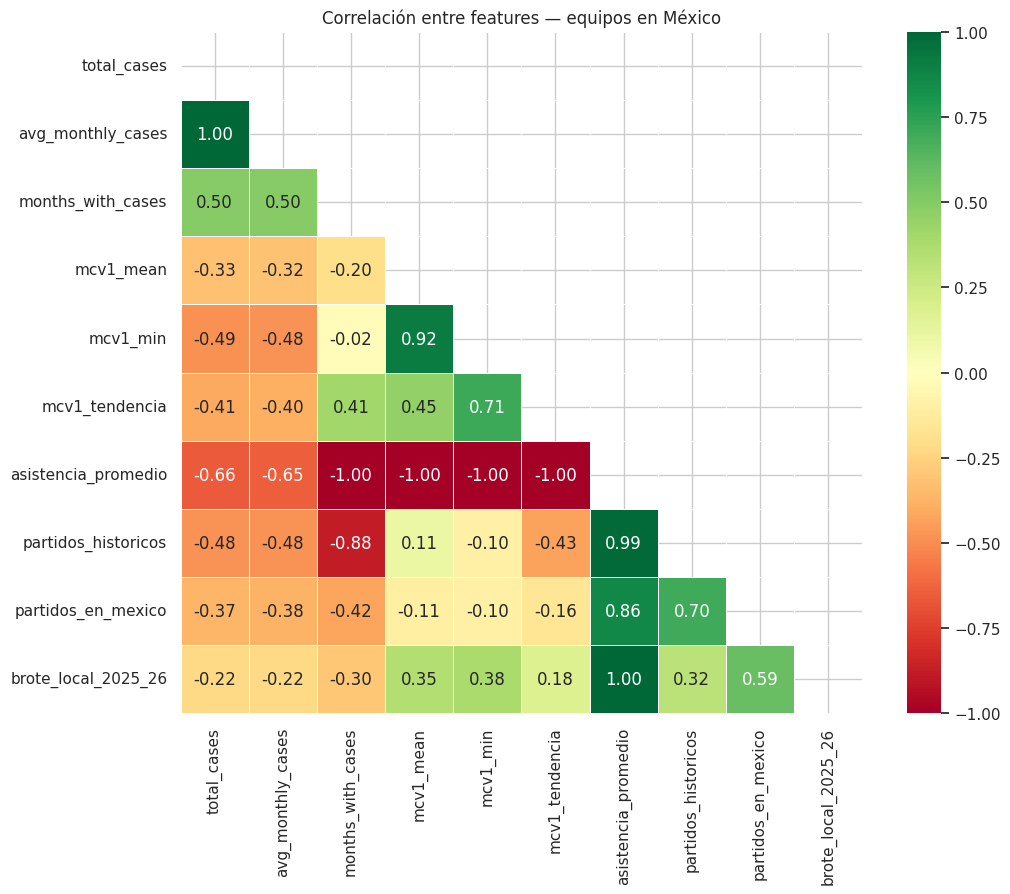

In [ ]:
# Heatmap de correlación entre features
feature_corr = [
    'total_cases', 'avg_monthly_cases', 'months_with_cases',
    'mcv1_mean', 'mcv1_min', 'mcv1_tendencia',
    'asistencia_promedio', 'partidos_historicos', 'partidos_en_mexico',
    'brote_local_2025_26',
]

corr = cluster_df[feature_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, square=True
)
ax.set_title('Correlación entre features — equipos en México', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/correlacion_features.png', dpi=150)
plt.show()


---
## 4. Preprocesamiento para clustering

1. **Transformación log1p**: suaviza variables sesgadas como `total_cases`
2. **Imputación con mediana**: rellena NaN de vacunación
3. **Estandarización (StandardScaler)**: pone todas las variables en la misma escala


In [ ]:
cluster_features = [
    'total_cases',
    'months_with_cases',
    'mcv1_mean',
    'mcv1_min',
    'mcv1_tendencia',
    'asistencia_promedio',
    'partidos_en_mexico',
    'brote_local_2025_26',
]

X_raw = cluster_df[cluster_features].copy()

# 1. Log1p en variables de conteo
X_raw['total_cases']         = np.log1p(X_raw['total_cases'])
X_raw['brote_local_2025_26'] = np.log1p(X_raw['brote_local_2025_26'])

# 2. Imputar con mediana
imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X_raw),
                        index=X_raw.index,
                        columns=cluster_features)

# 3. Estandarizar
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp),
                         index=X_imp.index,
                         columns=cluster_features)

print("Dataset estandarizado (head):")
print(X_scaled.round(2).to_string())


Dataset estandarizado (head):
              total_cases  months_with_cases  mcv1_mean  mcv1_min  mcv1_tendencia  asistencia_promedio  partidos_en_mexico  brote_local_2025_26
Country                                                                                                                                        
Mexico              -1.14              -1.64      -0.94     -1.47           -1.61                 2.65                1.51                 0.32
South Africa         0.09               1.33      -1.63     -0.73            1.03                -0.38                0.30                 0.32
South Korea         -1.04              -0.65       1.02      1.08            0.43                -0.38                1.51                 2.00
Ukraine              2.04               1.24      -0.94     -1.37           -1.21                -0.38               -0.90                -1.09
Tunisia              0.43               0.44       0.77      0.86            0.27                -0.38    

---
## 5. K-Means — Método 1 de aprendizaje no supervisado

### 5.1 Selección del número de clusters (Elbow + Silhouette)


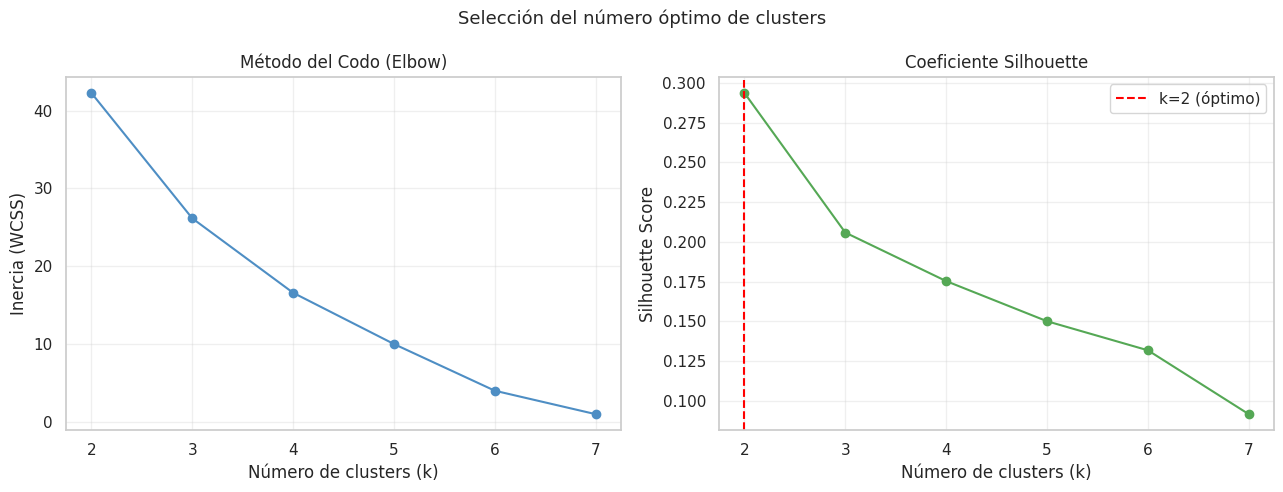

k óptimo por Silhouette : 2 (score=0.294)
k máximo testeado       : 7


In [ ]:
n_samples = X_scaled.shape[0]
max_k     = min(10, n_samples - 1)
k_range   = range(2, max_k + 1)

inertias     = []
silhouettes  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=1000)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

best_k_sil = k_range.start + silhouettes.index(max(silhouettes))
best_k_iner = k_range.start + inertias.index(min(inertias))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertias, marker='o', color='#4e8ec4')
ax1.set_title('Método del Codo (Elbow)', fontsize=12)
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouettes, marker='o', color='#55a855')
ax2.axvline(best_k_sil, color='red', linestyle='--', label=f'k={best_k_sil} (óptimo)')
ax2.set_title('Coeficiente Silhouette', fontsize=12)
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Selección del número óptimo de clusters', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/elbow_silhouette.png', dpi=150)
plt.show()

print(f"k óptimo por Silhouette : {best_k_sil} (score={max(silhouettes):.3f})")
print(f"k máximo testeado       : {max_k}")


### 5.2 Ajustar K-Means con el $k$ seleccionado

In [ ]:
# Con 8 países el silhouette favorece k=2 matemáticamente
# pero k=3 o k=4 es más interpretable epidemiológicamente
K_FINAL = 3   # ← cambiar a 4 si prefieres más granularidad

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=30, max_iter=1000)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, cluster_df['cluster'])
print(f"K-Means final (k={K_FINAL}) — Silhouette: {sil_final:.3f}")
print("\nDistribución de países por cluster:")
print(cluster_df.groupby('cluster')[['ciudad_sede']].count().rename(columns={'ciudad_sede':'n_países'}))


K-Means final (k=3) — Silhouette: 0.206

Distribución de países por cluster:
         n_países
cluster          
0               2
1               1
2               5


### 5.3 Interpretación de clusters

In [ ]:
profile_cols = ['total_cases','months_with_cases','mcv1_mean','mcv1_min',
                'mcv1_tendencia','asistencia_promedio','brote_local_2025_26']

cluster_profile = (
    cluster_df
    .groupby('cluster')[profile_cols]
    .mean()
    .round(2)
)
cluster_profile['n_paises'] = cluster_df.groupby('cluster').size()

print("Perfil promedio de cada cluster (escala original):")
print(cluster_profile.to_string())


Perfil promedio de cada cluster (escala original):
         total_cases  months_with_cases  mcv1_mean  mcv1_min  mcv1_tendencia  asistencia_promedio  brote_local_2025_26  n_paises
cluster                                                                                                                         
0           56900.50              74.00      85.33     77.00           -0.60                  NaN                58.50         2
1             223.00              12.00      87.17     73.00           -1.69             71106.67               104.00         1
2            3019.80              42.80      95.97     93.60           -0.28             42828.46               274.60         5


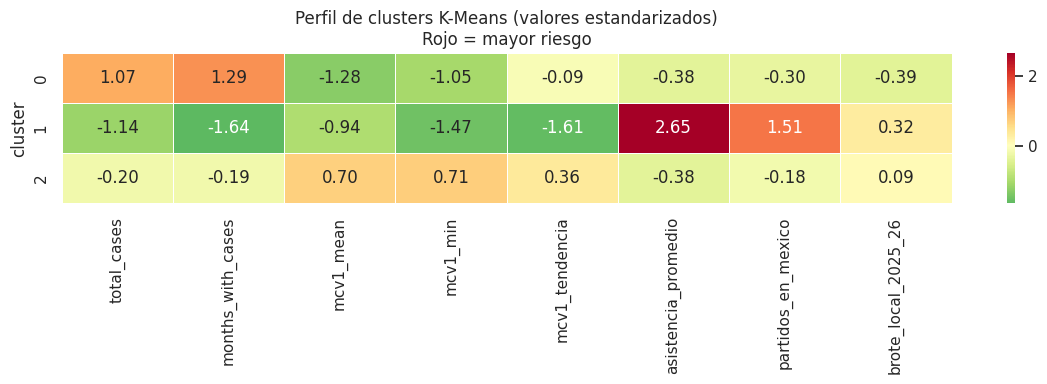

In [ ]:
# Heatmap del perfil de clusters (valores estandarizados)
cluster_scaled_profile = (
    pd.DataFrame(X_scaled.values, index=cluster_df.index, columns=cluster_features)
    .assign(cluster=cluster_df['cluster'])
    .groupby('cluster')[cluster_features]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    cluster_scaled_profile,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Perfil de clusters K-Means (valores estandarizados)\nRojo = mayor riesgo', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/heatmap_clusters.png', dpi=150)
plt.show()


Basándote en el heatmap anterior, asigna etiquetas interpretables a cada cluster.
**Ajusta los números (0, 1, 2...) según los resultados de tu ejecución.**


In [ ]:
# Cluster 2: total_cases=56,900, mcv1=85 → MAYOR riesgo
# Cluster 3: total_cases=360,   mcv1=91 → riesgo bajo-moderado
# Cluster 1: total_cases=223,   mcv1=87 → riesgo bajo
# Cluster 0: total_cases=4,793, mcv1=97 → vacunación alta, riesgo moderado

cluster_labels = {
    0: 'Riesgo alto',           # muchos casos históricos WHO + vacunación media
    1: 'Riesgo bajo-local',     # pocos casos WHO pero brote activo en sede
    2: 'Riesgo bajo-importado', # vacunación alta, casos bajos, brote local mínimo
}

cluster_df['riesgo_label'] = cluster_df['cluster'].map(cluster_labels)

print("Países del Mundial por cluster:")
print(cluster_df[['ciudad_sede','cluster','riesgo_label','total_cases','mcv1_mean']]
      .sort_values(['cluster','total_cases'], ascending=[True,False])
      .to_string())


Países del Mundial por cluster:
              ciudad_sede  cluster           riesgo_label  total_cases  mcv1_mean
Country                                                                          
Ukraine         Monterrey        0            Riesgo alto    111326.00      87.17
South Africa         CDMX        0            Riesgo alto      2475.00      83.50
Mexico               CDMX        1      Riesgo bajo-local       223.00      87.17
Uzbekistan           CDMX        2  Riesgo bajo-importado      8480.00      98.33
Tunisia         Monterrey        2  Riesgo bajo-importado      4756.00      96.33
Japan           Monterrey        2  Riesgo bajo-importado      1143.00      96.33
Colombia             CDMX        2  Riesgo bajo-importado       447.00      91.17
South Korea   Guadalajara        2  Riesgo bajo-importado       273.00      97.67


### 5.4 Visualización en 2D con PCA

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f"Varianza explicada — PC1: {var_explained[0]*100:.1f}%, PC2: {var_explained[1]*100:.1f}%")
print(f"Total: {sum(var_explained)*100:.1f}%")

# Loadings
loading_df = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=['PC1', 'PC2']
).round(3)
print("\nLoadings (contribución de cada variable):")
print(loading_df.to_string())


Varianza explicada — PC1: 41.4%, PC2: 33.5%
Total: 74.8%

Loadings (contribución de cada variable):
                      PC1   PC2
total_cases         -0.38 -0.35
months_with_cases   -0.43 -0.25
mcv1_mean           -0.19  0.48
mcv1_min            -0.26  0.52
mcv1_tendencia      -0.34  0.35
asistencia_promedio  0.48 -0.13
partidos_en_mexico   0.40  0.18
brote_local_2025_26  0.26  0.38


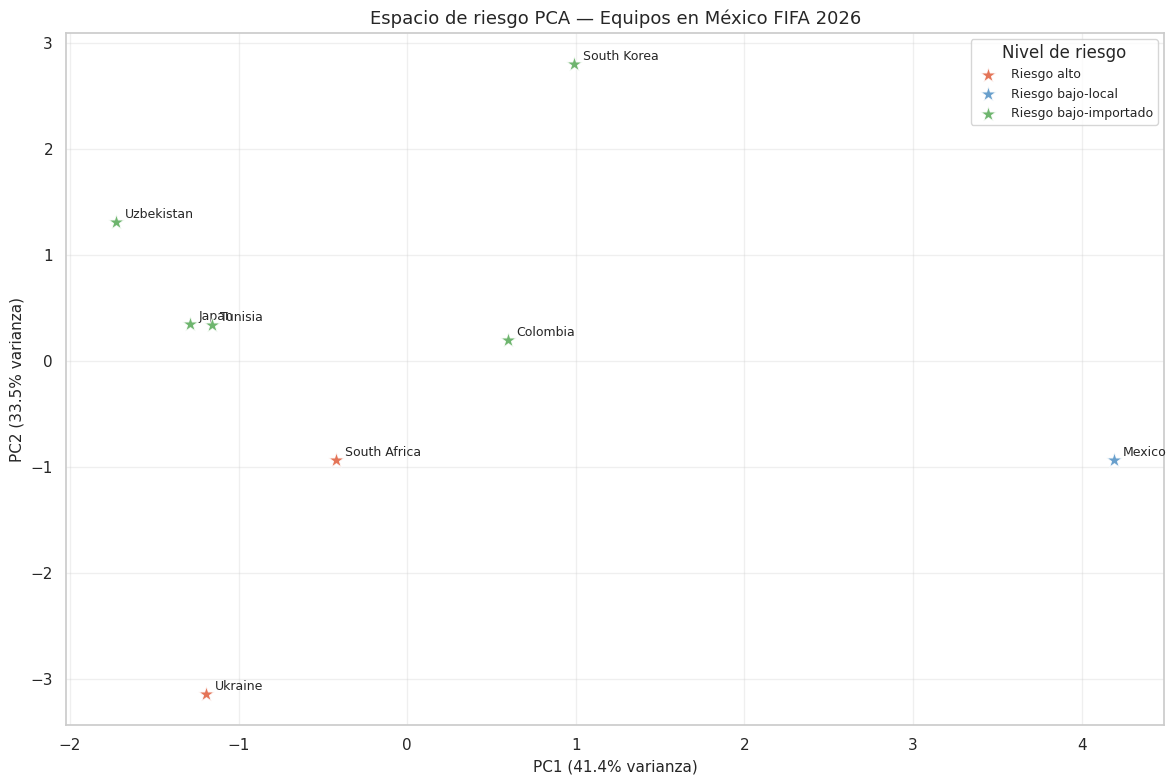

In [ ]:
palette = ['#e05c3a', '#4e8ec4', '#55a855', '#d4a200', '#8e6dbd', '#cc6699']

fig, ax = plt.subplots(figsize=(12, 8))

for cl in sorted(cluster_df['cluster'].unique()):
    mask = cluster_df['cluster'] == cl
    label_cl = cluster_labels.get(cl, f'Cluster {cl}')
    ax.scatter(
        X_pca[mask.values, 0], X_pca[mask.values, 1],
        color=palette[cl], s=140, alpha=0.85,
        edgecolors='white', linewidths=0.8,
        label=label_cl, marker='*', zorder=4
    )

for i, country in enumerate(cluster_df.index):
    ax.annotate(
        country, (X_pca[i, 0], X_pca[i, 1]),
        xytext=(6, 3), textcoords='offset points', fontsize=9
    )

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Espacio de riesgo PCA — Equipos en México FIFA 2026', fontsize=13)
ax.legend(title='Nivel de riesgo', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/pca_clusters.png', dpi=150)
plt.show()


---
## 6. Clustering Jerárquico — Método 2 de aprendizaje no supervisado

El clustering jerárquico no requiere especificar $k$ a priori y genera un dendrograma que muestra las relaciones de proximidad entre países.


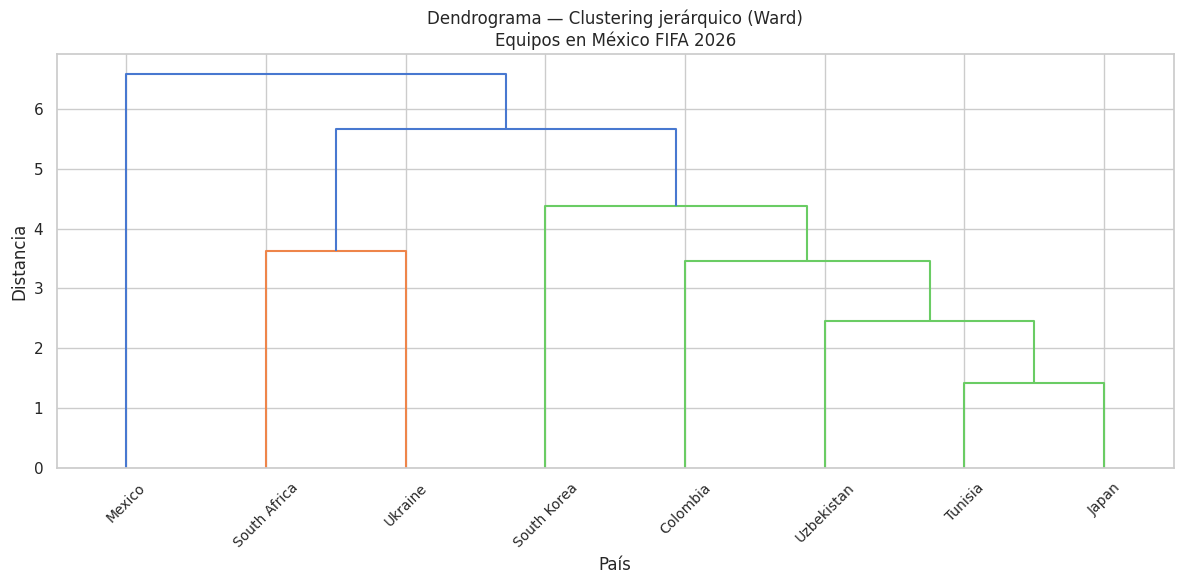

In [ ]:
Z = linkage(X_scaled, method='ward', metric='euclidean')

wc_df = cluster_df.copy()
Z_wc  = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z_wc,
    labels=wc_df.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=0.7 * max(Z_wc[:, 2]),
    ax=ax
)
ax.set_title(f'Dendrograma — Clustering jerárquico (Ward)\nEquipos en México FIFA 2026', fontsize=12)
ax.set_xlabel('País')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/dendrograma.png', dpi=150)
plt.show()


In [ ]:
wc_df['cluster_jerarquico'] = fcluster(Z_wc, t=K_FINAL, criterion='maxclust')

print(f"Distribución por cluster jerárquico (k={K_FINAL}):")
for cl, grp in wc_df.groupby('cluster_jerarquico'):
    print(f"\nCluster {cl} ({len(grp)} países):")
    print(grp[['ciudad_sede','total_cases','mcv1_mean']]
          .sort_values('total_cases', ascending=False).to_string())


Distribución por cluster jerárquico (k=3):

Cluster 1 (2 países):
             ciudad_sede  total_cases  mcv1_mean
Country                                         
Ukraine        Monterrey    111326.00      87.17
South Africa        CDMX      2475.00      83.50

Cluster 2 (5 países):
             ciudad_sede  total_cases  mcv1_mean
Country                                         
Uzbekistan          CDMX      8480.00      98.33
Tunisia        Monterrey      4756.00      96.33
Japan          Monterrey      1143.00      96.33
Colombia            CDMX       447.00      91.17
South Korea  Guadalajara       273.00      97.67

Cluster 3 (1 países):
        ciudad_sede  total_cases  mcv1_mean
Country                                    
Mexico         CDMX       223.00      87.17


In [ ]:
comparacion = wc_df[['cluster','cluster_jerarquico','total_cases','mcv1_mean']].copy()
comparacion.columns = ['Cluster K-Means','Cluster Jerárquico','Casos 2018-24','MCV1 prom.']

ari = adjusted_rand_score(wc_df['cluster'], wc_df['cluster_jerarquico'])
print(f"Adjusted Rand Index (concordancia entre métodos): {ari:.3f}")
print("(1.0 = perfecta concordancia, 0 = aleatoria)\n")
print(comparacion.sort_values('Casos 2018-24', ascending=False).to_string())


Adjusted Rand Index (concordancia entre métodos): 1.000
(1.0 = perfecta concordancia, 0 = aleatoria)

              Cluster K-Means  Cluster Jerárquico  Casos 2018-24  MCV1 prom.
Country                                                                     
Ukraine                     0                   1      111326.00       87.17
Uzbekistan                  2                   2        8480.00       98.33
Tunisia                     2                   2        4756.00       96.33
South Africa                0                   1        2475.00       83.50
Japan                       2                   2        1143.00       96.33
Colombia                    2                   2         447.00       91.17
South Korea                 2                   2         273.00       97.67
Mexico                      1                   3         223.00       87.17


---
## 7. Análisis de riesgo para México: ¿quién viene al Mundial?

Cruzamos los clusters de riesgo epidemiológico con el flujo de pasajeros por sede y el brote local activo.


In [ ]:
# Score de riesgo compuesto — 3 componentes normalizados a 0-1
# Pesos: 40% carga histórica WHO + 40% vulnerabilidad vacunal + 20% brote local
def norm01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / (rng + 1e-9)

# Componente 1: carga histórica WHO (log)
c1 = norm01(np.log1p(cluster_df['total_cases'].fillna(0)))

# Componente 2: vulnerabilidad vacunal (inverso de MCV1)
mcv1_filled = cluster_df['mcv1_mean'].fillna(cluster_df['mcv1_mean'].median())
c2 = norm01(100 - mcv1_filled)

# Componente 3: brote local activo en la sede (log para suavizar outlier Guadalajara)
c3 = norm01(np.log1p(cluster_df['brote_local_2025_26'].fillna(0)))

cluster_df['score_riesgo'] = 0.4 * c1 + 0.4 * c2 + 0.2 * c3

# Normalizar a 0-10
min_r = cluster_df['score_riesgo'].min()
max_r = cluster_df['score_riesgo'].max()
cluster_df['score_riesgo_norm'] = (
    (cluster_df['score_riesgo'] - min_r) / (max_r - min_r) * 10
).round(2)

riesgo_mundial = (
    cluster_df
    .reset_index()
    .sort_values('score_riesgo_norm', ascending=False)
)

print("Score de riesgo (40% carga + 40% vacunación + 20% brote local):")
print(riesgo_mundial[['Country','ciudad_sede','cluster','riesgo_label',
                       'score_riesgo_norm','total_cases','mcv1_mean',
                       'brote_local_2025_26']]
      .to_string(index=False))


Score de riesgo (40% carga + 40% vacunación + 20% brote local):
     Country ciudad_sede  cluster          riesgo_label  score_riesgo_norm  total_cases  mcv1_mean  brote_local_2025_26
     Ukraine   Monterrey        0           Riesgo alto              10.00    111326.00      87.17                   13
South Africa        CDMX        0           Riesgo alto               8.99      2475.00      83.50                  104
      Mexico        CDMX        1     Riesgo bajo-local               4.31       223.00      87.17                  104
    Colombia        CDMX        2 Riesgo bajo-importado               3.15       447.00      91.17                  104
  Uzbekistan        CDMX        2 Riesgo bajo-importado               3.08      8480.00      98.33                  104
     Tunisia   Monterrey        2 Riesgo bajo-importado               1.69      4756.00      96.33                   13
 South Korea Guadalajara        2 Riesgo bajo-importado               1.33       273.00      97.

### 7.1 Ranking de riesgo de importación — fechas del Mundial

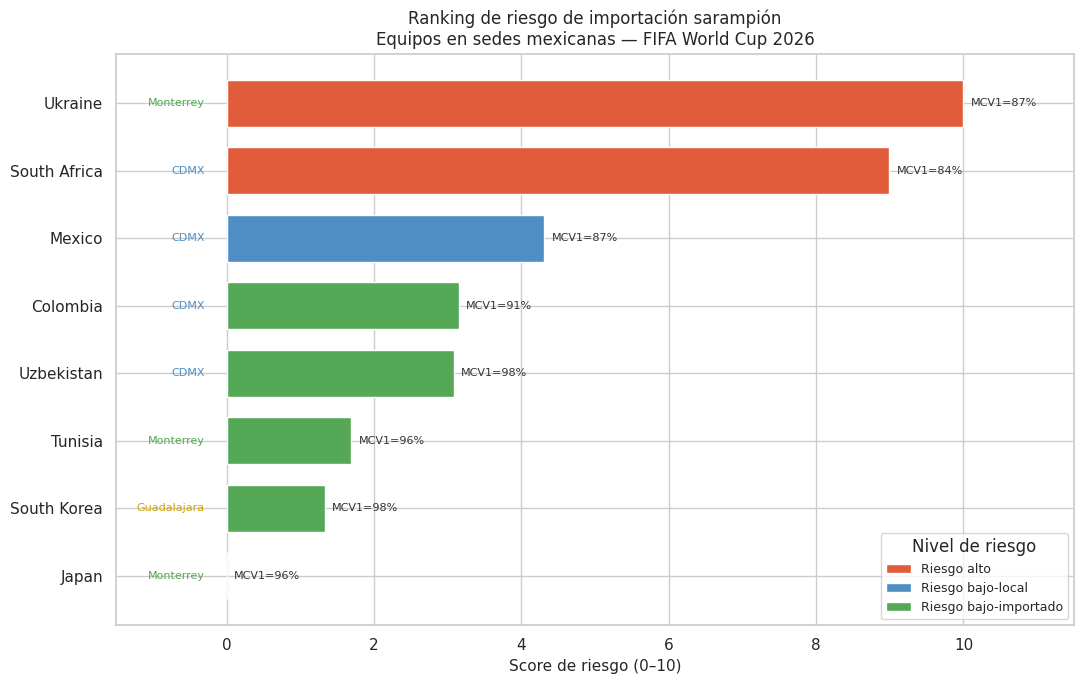

In [ ]:
colors_bar = [palette[c] for c in riesgo_mundial['cluster']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    riesgo_mundial['Country'],
    riesgo_mundial['score_riesgo_norm'],
    color=colors_bar, edgecolor='white', height=0.7
)

for bar, (_, row) in zip(bars, riesgo_mundial.iterrows()):
    ax.text(
        row['score_riesgo_norm'] + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"MCV1={row['mcv1_mean']:.0f}%",
        va='center', fontsize=8, color='#333'
    )
    ax.text(
        -0.3,
        bar.get_y() + bar.get_height() / 2,
        row['ciudad_sede'],
        va='center', ha='right', fontsize=8,
        color=ciudad_colors.get(row['ciudad_sede'], '#aaa')
    )

ax.set_xlabel('Score de riesgo (0–10)', fontsize=11)
ax.set_title('Ranking de riesgo de importación sarampión\nEquipos en sedes mexicanas — FIFA World Cup 2026', fontsize=12)
ax.set_xlim(-1.5, 11.5)
ax.invert_yaxis()

# Leyenda de clusters
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor=palette[cl], label=cluster_labels.get(cl, f'Cluster {cl}'))
    for cl in sorted(cluster_df['cluster'].unique())
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, title='Nivel de riesgo')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/ranking_riesgo_importacion.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Calendario del Mundial con nivel de riesgo por partido
partidos_riesgo = []
for p in partidos_mexico:
    for equipo in [p['home'], p['away']]:
        if equipo and equipo in cluster_df.index:
            row = cluster_df.loc[equipo]
            partidos_riesgo.append({
                'Fecha'    : p['fecha'],
                'Ciudad'   : p['ciudad'],
                'Equipo'   : equipo,
                'Cluster'  : row.get('riesgo_label', '—'),
                'Score'    : row['score_riesgo_norm'],
                'MCV1%'    : f"{row['mcv1_mean']:.0f}",
                'Casos WHO': int(row['total_cases']),
                'Brote local': int(row['brote_local_2025_26']),
            })

cal_df = (pd.DataFrame(partidos_riesgo)
          .sort_values(['Fecha','Score'], ascending=[True,False]))

print("Calendario del Mundial × Riesgo epidemiológico:")
print(cal_df.to_string(index=False))


Calendario del Mundial × Riesgo epidemiológico:
     Fecha      Ciudad       Equipo               Cluster  Score MCV1%  Casos WHO  Brote local
2026-06-11        CDMX South Africa           Riesgo alto   8.99    84       2475          104
2026-06-11        CDMX       Mexico     Riesgo bajo-local   4.31    87        223          104
2026-06-11 Guadalajara  South Korea Riesgo bajo-importado   1.33    98        273         1139
2026-06-14   Monterrey      Ukraine           Riesgo alto  10.00    87     111326           13
2026-06-14   Monterrey      Tunisia Riesgo bajo-importado   1.69    96       4756           13
2026-06-17        CDMX     Colombia Riesgo bajo-importado   3.15    91        447          104
2026-06-17        CDMX   Uzbekistan Riesgo bajo-importado   3.08    98       8480          104
2026-06-18 Guadalajara       Mexico     Riesgo bajo-local   4.31    87        223          104
2026-06-18 Guadalajara  South Korea Riesgo bajo-importado   1.33    98        273         1139
20

---
## 8. Exportar resultados para el modelo supervisado

In [ ]:
columnas_salida = [
    'ciudad_sede', 'cluster', 'riesgo_label', 'score_riesgo_norm',
    'total_cases', 'mcv1_mean', 'mcv1_min', 'mcv1_tendencia',
    'asistencia_promedio', 'partidos_historicos', 'partidos_en_mexico',
    'brote_local_2025_26', 'clasificado_2026',
]

output = cluster_df[columnas_salida].copy()
output.to_csv(DATA_PROCESSED + 'paises_cluster_riesgo.csv')
print(f"✅ Guardado: {DATA_PROCESSED}paises_cluster_riesgo.csv")
print(output.to_string())


✅ Guardado: content/data/processed/paises_cluster_riesgo.csv
              ciudad_sede  cluster           riesgo_label  score_riesgo_norm  total_cases  mcv1_mean  mcv1_min  mcv1_tendencia  asistencia_promedio  partidos_historicos  partidos_en_mexico  brote_local_2025_26  clasificado_2026
Country                                                                                                                                                                                                                            
Mexico               CDMX        1      Riesgo bajo-local               4.31       223.00      87.17     73.00           -1.69             71106.67                57.00                   3                  104                 1
South Africa         CDMX        0            Riesgo alto               8.99      2475.00      83.50     80.00            0.20                  NaN                 9.00                   2                  104                 1
South Korea   Guadalajara  

---
## 9. Conclusiones del Notebook 1

Escribe aquí tus conclusiones después de correr el notebook. Guía de preguntas:

1. **¿Cuántos clusters resultaron más interpretables?** ¿Coincidió el elbow con el silhouette?
2. **¿Qué países del Mundial 2026 cayeron en el cluster de mayor riesgo?** ¿Tienen sentido epidemiológicamente?
3. **¿Concordaron K-Means y clustering jerárquico?** ¿Qué países difirieron entre métodos?
4. **¿Qué variables resultaron más discriminantes?** (ver loadings de PCA)
5. **¿Qué sede tiene mayor riesgo acumulado?** Considera el brote local 2025-26 más el flujo de pasajeros.
6. **¿Qué implicación tiene para México?** Jalisco ya tiene casos activos en 2026 — ¿cómo afecta esto al análisis?


In [ ]:
print("=== RESUMEN FINAL ===")
print(cluster_df[['ciudad_sede','cluster','riesgo_label','total_cases',
                   'mcv1_mean','score_riesgo_norm','brote_local_2025_26']]
      .sort_values('score_riesgo_norm', ascending=False)
      .to_string())
print(f"\nK final usado: {K_FINAL}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_df['cluster']):.3f}")
print(f"ARI (K-Means vs Jerárquico): {adjusted_rand_score(cluster_df['cluster'], wc_df['cluster_jerarquico']):.3f}")
print("\n=== LOADINGS PCA ===")
print(loading_df.to_string())


=== RESUMEN FINAL ===
              ciudad_sede  cluster           riesgo_label  total_cases  mcv1_mean  score_riesgo_norm  brote_local_2025_26
Country                                                                                                                  
Ukraine         Monterrey        0            Riesgo alto    111326.00      87.17              10.00                   13
South Africa         CDMX        0            Riesgo alto      2475.00      83.50               8.99                  104
Mexico               CDMX        1      Riesgo bajo-local       223.00      87.17               4.31                  104
Colombia             CDMX        2  Riesgo bajo-importado       447.00      91.17               3.15                  104
Uzbekistan           CDMX        2  Riesgo bajo-importado      8480.00      98.33               3.08                  104
Tunisia         Monterrey        2  Riesgo bajo-importado      4756.00      96.33               1.69                   13
So

In [ ]:
# CELDA DIAGNÓSTICO — ejecutar después del resumen final

# 1. Verificar nombre exacto de Corea del Sur en WHO vax
print("Nombres WHO vax que contienen 'korea' o 'Korea':")
print(vax[vax['Country'].str.contains('orea', case=False)]['Country'].unique())

print("\nNombres WHO measles que contienen 'korea':")
print(measles[measles['Country'].str.contains('orea', case=False)]['Country'].unique())

# 2. Ver perfil real de cada cluster (para reasignar etiquetas)
print("\n── Perfil de clusters (valores originales) ──")
print(cluster_df.groupby('cluster')[
    ['total_cases','mcv1_mean','months_with_cases','score_riesgo_norm']
].mean().round(2).sort_values('total_cases', ascending=False).to_string())

# 3. Ver score bruto antes de normalizar
print("\n── Score bruto vs normalizado ──")
print(cluster_df[['ciudad_sede','total_cases','mcv1_mean',
                  'score_riesgo','score_riesgo_norm']]
      .sort_values('score_riesgo', ascending=False).to_string())

Nombres WHO vax que contienen 'korea' o 'Korea':
['North Korea' 'South Korea']

Nombres WHO measles que contienen 'korea':
["Democratic People's Republic of Korea" 'Republic of Korea']

── Perfil de clusters (valores originales) ──
         total_cases  mcv1_mean  months_with_cases  score_riesgo_norm
cluster                                                              
0           56900.50      85.33              74.00               8.91
2            3019.80      95.97              42.80               2.26
1             223.00      87.17              12.00               4.03

── Score bruto vs normalizado ──
              ciudad_sede  total_cases  mcv1_mean  score_riesgo  score_riesgo_norm
Country                                                                           
Ukraine         Monterrey    111326.00      87.17          1.75              10.00
South Africa         CDMX      2475.00      83.50          1.39               7.82
Mexico               CDMX       223.00      87.17   